# Riproduzione Errore *visualize_plot*

In [1]:
# Typical imports
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR, generate_bitstring_combinations

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

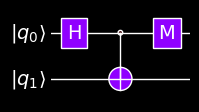

In [2]:
qc = Circuit(2)

qc.add([ gates.H(0), gates.CNOT(0,1), gates.M(0) ])
plot_circuit(qc, style=custom_style)
plt.show()

In [3]:
# Execute the circuit with 1024 shots

res = qc(nshots=2**10)

[Qibo 0.2.22|INFO|2025-11-20 13:58:41]: Using qibojit (numba) backend on /CPU:0


## Errore:
Il plot tramite frequencies non funziona

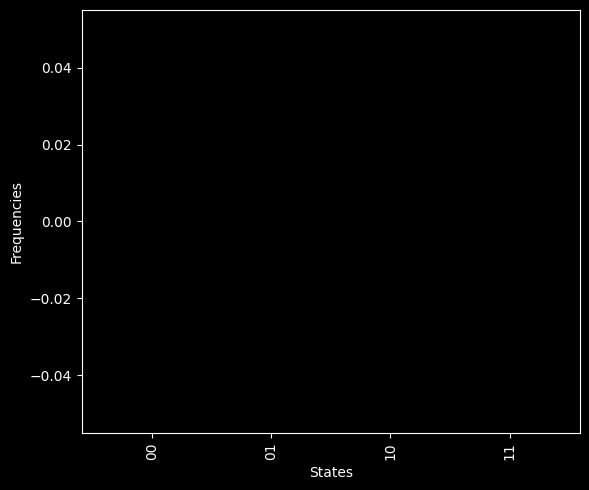

In [4]:
# Plot measurement histogram through frequencies
visualize_state(res, mode="frequencies")
plt.show()

# Soluzione

In [25]:
from typing import List, Optional, Union

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from qibo.backends import _check_backend
from qibo.config import raise_error
from qibo.result import CircuitResult, MeasurementOutcomes, QuantumState
from qibo.ui.drawing_utils import (
    QIBO_COMPLEMENTARY_COLOR,
    QIBO_DEFAULT_COLOR,
    generate_bitstring_combinations,
)

In [ ]:
def visualize_state_corrected(
    execution_outcome: Union[QuantumState, MeasurementOutcomes, CircuitResult],
    mode: str = "probabilities",
    n_most_relevant_components=None,
):
    """
    Plot circuit execution's result data according to the chosen ``mode``.

    Args:
        execution_outcome: qibo circuit's result. Depending on the simulation
            preferences, some of the visualizations can be accessed and some of them
            not. In particular:
                - if ``execution_outcome`` is a `QuantumState`, only probabilities and
                  amplitudes can be visualized;
                - if ``execution_outcome`` is a ``MeasurementOutcomes``, then all
                  the ``mode`` options are available.
        mode: visualization mode can be "amplitudes", "probabilities" or "frequencies".
            Default is "probabilities".
        n_most_relevant_components (int): in case the system is big (more than a few
            qubits), it can be helpful to reduce the number of ticks in the x-axis.
            To do so, this argument can be set, reducing the number of plotted ticks
            to `n_most_relevant_components`. Default is None.
    """
    # Collect amplitude
    amplitudes = execution_outcome.backend.to_numpy(execution_outcome.state())
    nqubits = int(np.log2(len(amplitudes)))

    bitstrings = generate_bitstring_combinations(nqubits)

    num_bitstrings = len(bitstrings)

    fig_width = max(6, nqubits * 1.5)
    fig_height = 5

    _, ax = plt.subplots(figsize=(fig_width, fig_height))

    x = np.arange(num_bitstrings)

    ax.set_xlabel("States")
    ax.set_ylabel(mode.capitalize())

    if mode == "frequencies":

        # ------- Correction starts here -------
        nqubits = len(execution_outcome.measurements)
        bitstrings = generate_bitstring_combinations(nqubits)
        num_bitstrings = len(bitstrings)
        x = np.arange(num_bitstrings)
        # ------- Correction ends here -------
        
        if not isinstance(execution_outcome, MeasurementOutcomes):
            raise_error(
                ValueError,
                "To visualize frequencies, ensure the circuit is executed with shots.",
            )
        frequencies = execution_outcome.frequencies()
        y_values = [frequencies.get(b, 0) for b in bitstrings]
        ax.bar(x, y_values, color=QIBO_DEFAULT_COLOR, edgecolor="black")

    elif mode == "amplitudes":
        real_parts = np.real(amplitudes)
        imag_parts = np.imag(amplitudes)
        width = 0.3
        ax.bar(
            x - width / 2,
            real_parts,
            width,
            color=QIBO_DEFAULT_COLOR,
            edgecolor="black",
            label="Real part",
        )
        ax.bar(
            x + width / 2,
            imag_parts,
            width,
            color=QIBO_COMPLEMENTARY_COLOR,
            edgecolor="black",
            label="Imag part",
        )
        ax.hlines(0, -1, num_bitstrings, color="black", lw=1)
        ax.legend()
        y_values = np.abs(amplitudes)

    elif mode == "probabilities":
        probabilities = np.abs(amplitudes) ** 2
        ax.bar(x, probabilities, color=QIBO_DEFAULT_COLOR, edgecolor="black")
        y_values = probabilities

    else:
        raise_error(
            ValueError,
            f"Unsupported mode '{mode}'. Choose 'amplitudes', 'probabilities' or 'frequencies'.",
        )

    # Adjust x-axis labels based on number of qubits
    if n_most_relevant_components is not None:
        top_indices = np.argsort(y_values)[-n_most_relevant_components:]
        tick_labels = [
            bitstrings[i] if i in top_indices else "" for i in range(num_bitstrings)
        ]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=90)
    else:
        ax.set_xticks(x)
        ax.set_xticklabels(bitstrings, rotation=90)

    plt.tight_layout()

    return ax, ax.figure

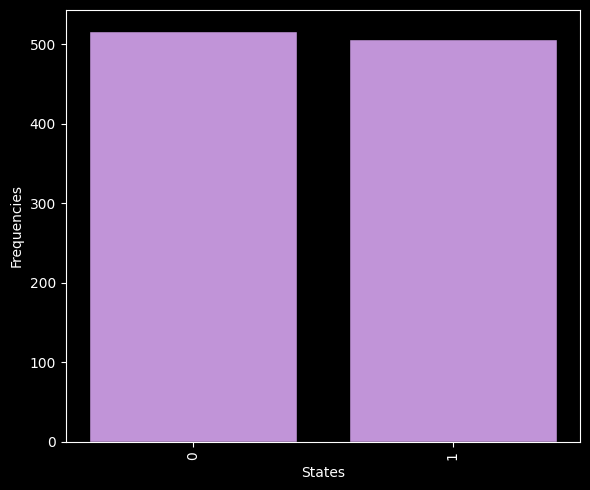

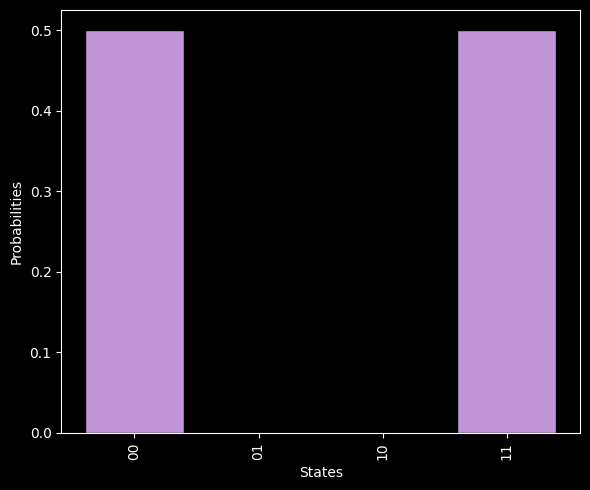

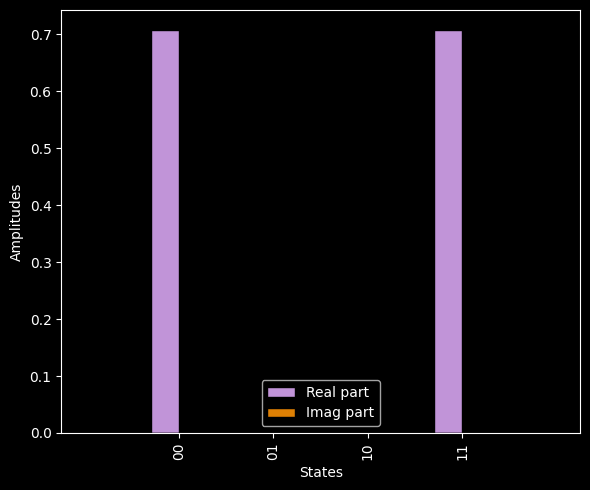

In [57]:
visualize_state_corrected(res, mode="frequencies")
visualize_state_corrected(res, mode="probabilities")
visualize_state_corrected(res, mode="amplitudes")
plt.show()